# Project Milestone One: Form Your Team, Understand the Problem, and Explore the Data

#### **Due:** July 12th @ 11:59 PM (with a 2 hour & 1 minute grace period)

#### **Important:** There is **no late period** for this assignment, as manual grading must begin immediately after the deadline.

## What You Will Do in This Milestone

1. Form your project team and complete the **Team Contract** (available in the Homework Repository). Submit one copy to Gradescope.
2. Select a **team leader**, who will submit this notebook on behalf of the team after everyone has contributed to the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>Gradescope guide</a> explains how to add group members to a submission.
3. After completing this milestone, **each team member** must complete an **Individual Team Evaluation** (available in the Homework Repository) and submit it individually to Gradescope.
4. Complete a simplified version of the **Machine Learning Project Checklist** from Appendix A of *Hands-On Machine Learning* (p. 779):

> **Part 1:** Frame the problem and understand the project goals   
> **Part 2:** Explore and understand the dataset   
> **Part 3:** Clean and prepare the data   
> **Part 4:** Investigate feature relationships   
> **Part 5:** Develop hypotheses for feature engineering and preprocessing

## The Dataset

All teams will work with the same dataset: a reduced version of the Zillow housing dataset used in the **Zillow Prize** competition on Kaggle in 2017 (unfortunately, the competition has long since ended!).

Your goal is to predict a property's **assessed tax value** (`taxvaluedollarcnt`) from a large collection of property characteristics. The dataset contains many of the challenges encountered in real machine learning projects, including:

* Missing values
* Potential outliers
* Redundant and highly correlated features
* Identifier variables that may not be useful for prediction
* Features that require careful interpretation before preprocessing

Unlike many educational datasets, this one has **not** been extensively preprocessed. Throughout this milestone, your objective is to understand the data, identify potential issues, and develop hypotheses about preprocessing and feature engineering. In **Milestone 2**, you will evaluate many of these ideas experimentally to determine whether they actually improve model performance.



In [185]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.**

For a detailed description of the dataset features, please refer to  **Appendix 1** below.


In [186]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercising all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data;
- Develop a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:**

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

> For our team project we would like to focus on business perspective, where the main objective is to use property characteristics to build a regression model that accurately predicts assessed tax values. For Zillow, having reliable tax estimates directly affects user retention and platform trust. Looking at this from a marketing standpoint, the model gives the team a data-driven way to target specific user segments. Marketing can leverage the model's insights to build new features—like homeownership cost calculators—that drive high-intent traffic to the site and give Zillow a clear advantage over competitors.

**1.2:**  How will your solution be used?

> Once the regression model is trained and optimized, it will be integrated into Zillow's backend data pipeline to generate real-time tax predictions as new property listings come in. On the front end, this solution will automatically display the estimated tax values directly on the property pages for users to see. Internally, the marketing team will use the model's outputs to segment customer data, allowing them to target specific buyer types with personalized email campaigns or targeted ad placements based on regional housing trends.

**1.3:**  How should success (or failure) be measured?

> Success will be measured using a mix of data science metrics and marketing performance indicators. On the technical side, we want to minimize our prediction error using metrics like Mean Absolute Error (MAE) or Root Mean Squared Error (RMSE) so the model is reliable. For the marketing team, success means the new features actively drive user engagement, which we can measure through increased page views, longer session durations, and higher conversion rates on targeted ads. If the model has a massive error rate that misleads buyers and hurts Zillow's reputation for accurate data, the project would be considered a failure.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Feature Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process.
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [187]:
# Quick look at the first few rows
print(df.head())

# Check data types and missing value counts
print(df.info())

# Check how many unique values are in each column
print(df.nunique())

# Calculate and explicitly show the missing value percentages
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
print(missing_pct.sort_values(ascending=False))

   parcelid  airconditioningtypeid  architecturalstyletypeid  basementsqft  \
0  14297519                    NaN                       NaN           NaN   
1  17052889                    NaN                       NaN           NaN   
2  14186244                    NaN                       NaN           NaN   
3  12177905                    NaN                       NaN           NaN   
4  10887214                    1.0                       NaN           NaN   

   bathroomcnt  bedroomcnt  buildingclasstypeid  buildingqualitytypeid  \
0          3.5         4.0                  NaN                    NaN   
1          1.0         2.0                  NaN                    NaN   
2          2.0         3.0                  NaN                    NaN   
3          3.0         4.0                  NaN                    8.0   
4          3.0         3.0                  NaN                    8.0   

   calculatedbathnbr  decktypeid  finishedfloor1squarefeet  \
0                3.5    

#### **2.A Discussion:**

Answer the following questions. You may wish to examine Appendix 3 before starting.

**2.A.1:**  Which features are categorical?

> According to the Appendix 3 flowchart, we cannot just rely on Python data types to identify categorical features. Even though many of these columns are stored as floats or integers, they are actually ID codes representing distinct categories with no meaningful numerical ordering. The clearest examples of these are the explicit identifier codes like *airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, heatingorsystemtypeid*, and *propertylandusetypeid*, along with regional codes like *fips, regionidcity, regionidcounty,* and *regionidzip*. Additionally, there are several text descriptions and boolean flags that act as nominal categorical variables. This includes *propertycountylandusecode, propertyzoningdesc, hashottuborspa, fireplaceflag, taxdelinquencyflag*, and the various pool type indicators (*pooltypeid10, pooltypeid2, pooltypeid7*). All of these will need proper encoding before we can feed them into our regression model.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

> Yes, there are a few features that are functionally useless for our regression task. The primary example is *parcelid*. Because it is strictly a unique key identifier for each property, it holds zero predictive power, and keeping it would just cause our model to overfit. Another example is *assessmentyear*—since every single entry is from 2016, this column has zero variance and gives the model no helpful information to learn from. Finally, features like *rawcensustractandblock* and *censustractandblock* are raw geographic ID codes that are completely redundant since we already have the exact *latitude* and *longitude* coordinates to handle location data. All of these can be safely dropped before training.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

> Yes, several features have a massive percentage of missing values that make them functionally useless for our model. As shown by the explicitly calculated percentages in the code above, features like *buildingclasstypeid* and *basementsqft* are missing over 99.9% of their data. Because there is virtually no data for the regression model to learn a meaningful relationship from, keeping these columns and plugging in estimated values would introduce too much artificial bias. Explicitly identifying these massive gaps here also gives us a clear baseline for what needs to be dropped versus what can be salvaged during the imputation phase in Part 3.E.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

> Yes, several features appear to be completely useless for our model because they have only one unique value across the entire dataset, meaning they have zero variance. Looking at our *.nunique()* output, this list includes *assessmentyear, taxdelinquencyflag, poolcnt, hashottuborspa, fireplaceflag, storytypeid, decktypeid, pooltypeid10, pooltypeid2,* and *pooltypeid7*. A feature with zero variance gives our regression model absolutely no information to split on or calculate weights for. For example, since every property's *assessmentyear* is recorded as 2016, this column cannot help explain why one home's tax value might be higher or lower than another's. Because they offer zero predictive value, all of these single-value features should be safely removed.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the target and three (3) additional features that you believe are particularly informative or interesting (a total of four features):
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

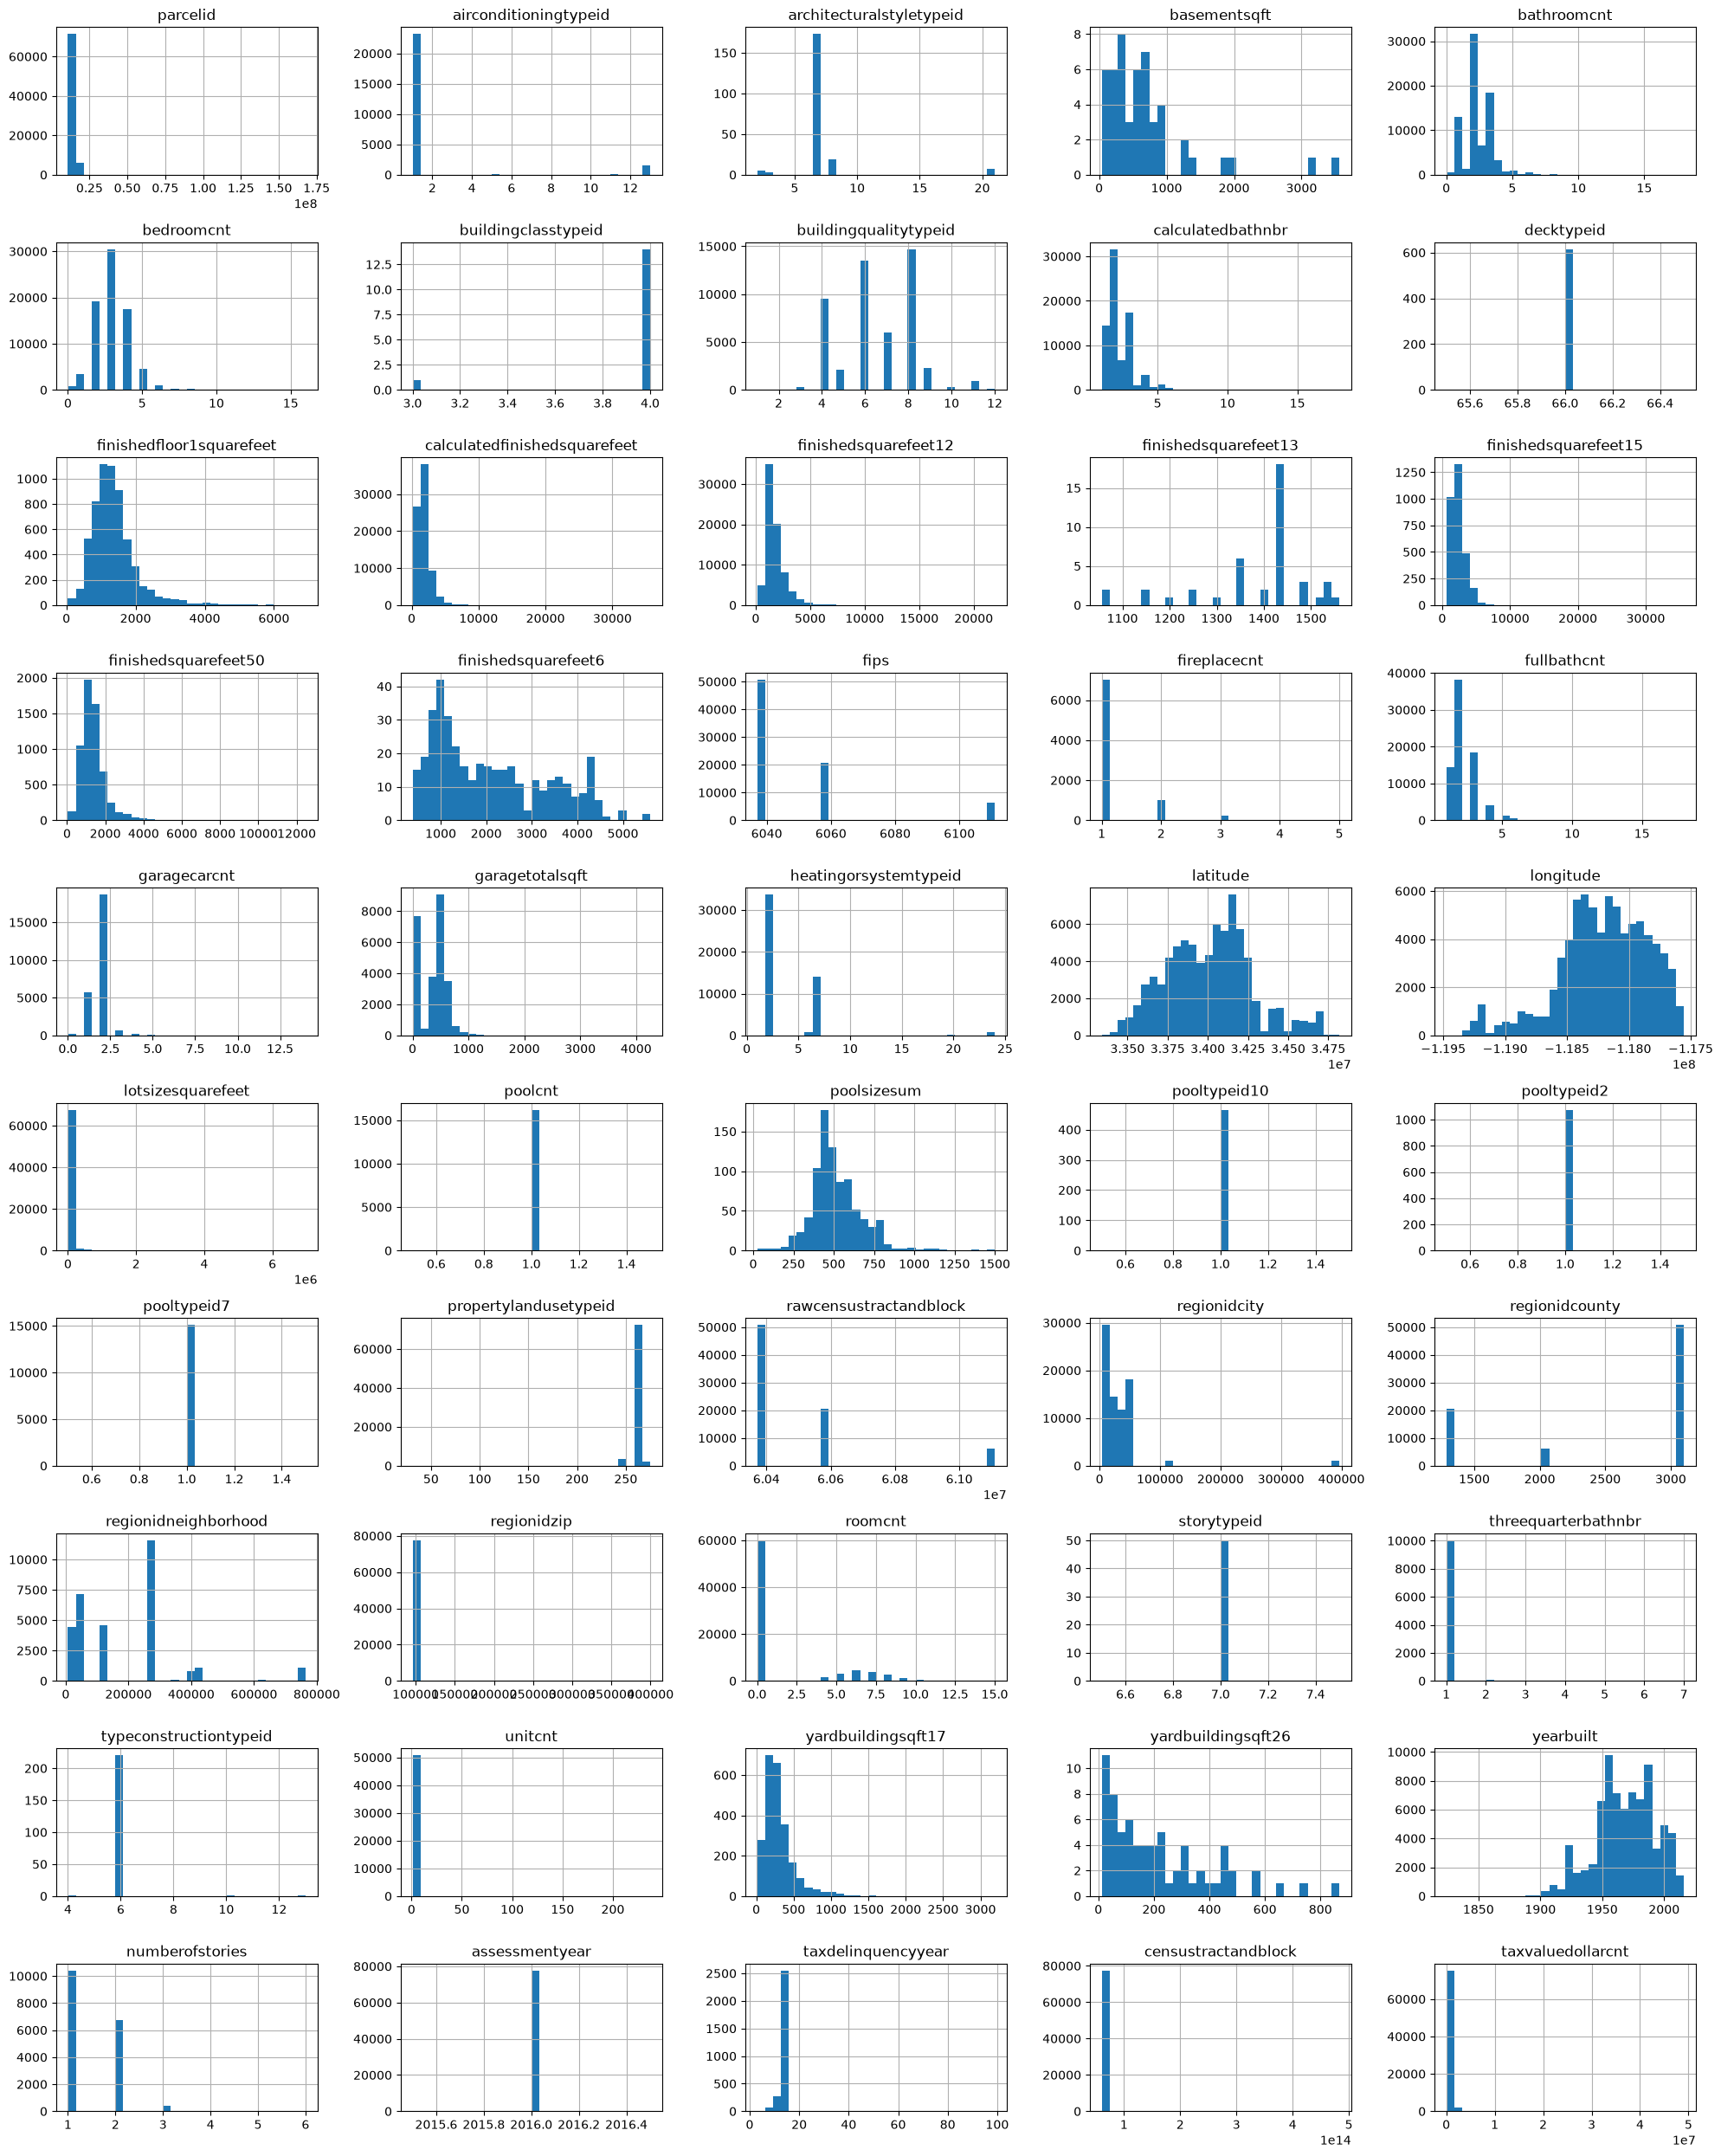

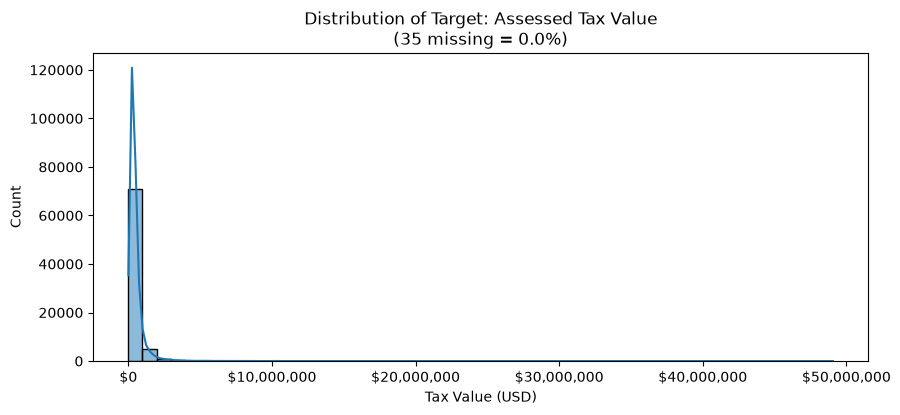

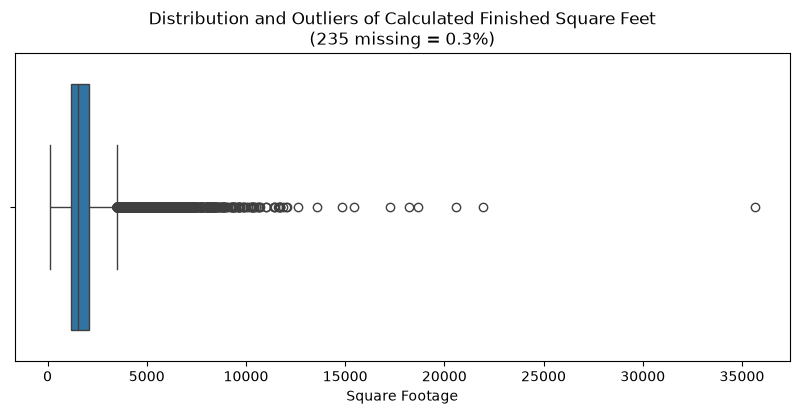

C:\Users\ouyan\AppData\Local\Temp\ipykernel_27596\3265843404.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col].dropna(), palette='Blues_d')


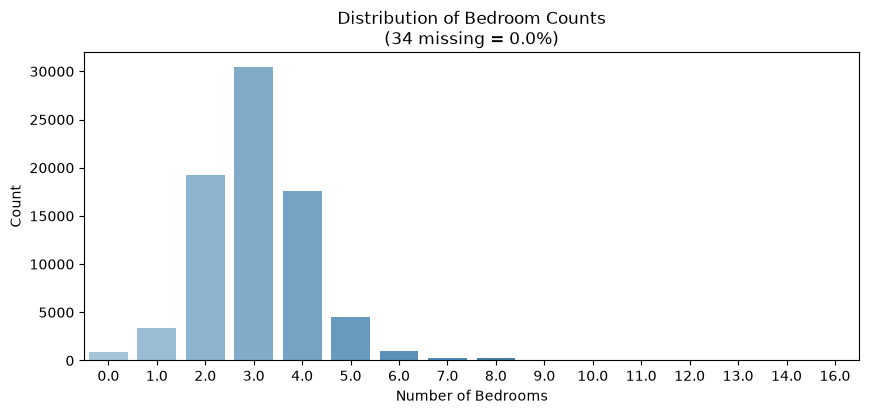

C:\Users\ouyan\AppData\Local\Temp\ipykernel_27596\3265843404.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col].dropna(), palette='viridis')


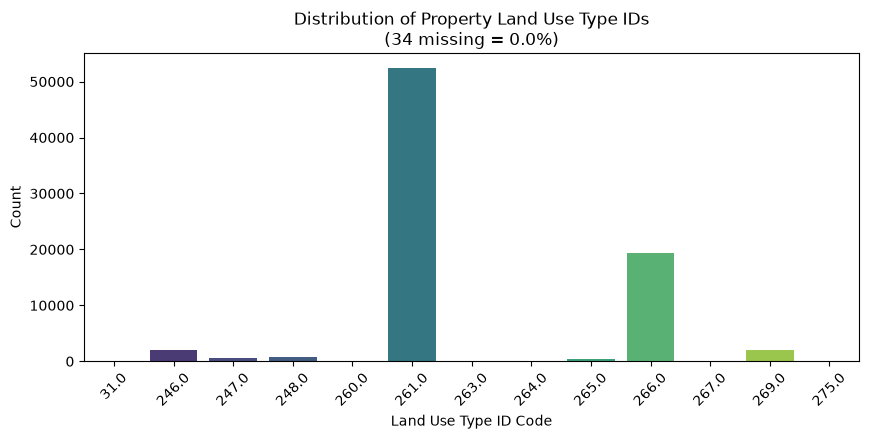

In [188]:
# 1. Overall view: Generate histograms for all features in the dataset
df.hist(figsize=(20, 25), layout=(-1, 5), bins=30)
plt.tight_layout()
plt.show()

# 2. Detailed Focus: Target variable (taxvaluedollarcnt)
col = 'taxvaluedollarcnt'
n_missing = df[col].isna().sum()
pct_missing = (n_missing / len(df) * 100).round(1)

plt.figure(figsize=(10, 4))
sns.histplot(df[col].dropna(), bins=50, kde=True)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
plt.title(f'Distribution of Target: Assessed Tax Value\n({n_missing} missing = {pct_missing}%)')
plt.xlabel('Tax Value (USD)')
plt.ylabel('Count')
plt.show()

# 3. Feature 1: calculatedfinishedsquarefeet (Continuous Numerical)
col = 'calculatedfinishedsquarefeet'
n_missing = df[col].isna().sum()
pct_missing = (n_missing / len(df) * 100).round(1)

plt.figure(figsize=(10, 4))
sns.boxplot(x=df[col].dropna())
plt.title(f'Distribution and Outliers of Calculated Finished Square Feet\n({n_missing} missing = {pct_missing}%)')
plt.xlabel('Square Footage')
plt.show()

# 4. Feature 2: bedroomcnt (Discrete Numerical)
col = 'bedroomcnt'
n_missing = df[col].isna().sum()
pct_missing = (n_missing / len(df) * 100).round(1)

plt.figure(figsize=(10, 4))
sns.countplot(x=df[col].dropna(), palette='Blues_d')
plt.title(f'Distribution of Bedroom Counts\n({n_missing} missing = {pct_missing}%)')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count')
plt.show()

# 5. Feature 3: propertylandusetypeid (Categorical Identifier)
col = 'propertylandusetypeid'
n_missing = df[col].isna().sum()
pct_missing = (n_missing / len(df) * 100).round(1)

plt.figure(figsize=(10, 4))
sns.countplot(x=df[col].dropna(), palette='viridis')
plt.title(f'Distribution of Property Land Use Type IDs\n({n_missing} missing = {pct_missing}%)')
plt.xlabel('Land Use Type ID Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### **2.B Discussion:**

Describe what you learned from your detailed examination of the four features you selected. For each feature, discuss:

- The overall distribution (for example, approximately normal, skewed, or multimodal).
- Any notable characteristics, such as outliers, unusual values, or missing data.
- Why you selected the feature and what you learned about the dataset from examining it.

Conclude by briefly discussing whether any of the features you examined might require additional preprocessing later in the project (such as imputation, transformation, or outlier investigation).

> **Target Feature: taxvaluedollarcnt (Assessed Tax Value)**
> * **Distribution & Characteristics:** The distribution of our target variable is heavily right-skewed. The vast majority of properties are clustered under $1 million, but a few massive luxury estate values stretch out into a long right tail, indicating heavy outliers.
> * **Reason for Selection:** As our target variable, understanding its distribution is essential. Because it is highly skewed, running a linear regression model directly on it could cause the model to be heavily influenced by multi-million dollar outliers, meaning we will likely need a log transformation later.


> **Feature 1: calculatedfinishedsquarefeet (Total Finished Living Area)**
> * **Distribution & Characteristics:** Similar to the target, this distribution is heavily right-skewed. The boxplot reveals a high density of extreme outliers on the right side, showcasing mansions with massive square footage compared to typical residential homes.
> * **Reason for Selection:** We selected this because a home's size usually correlates strongly with its value. Examining it confirms that real estate size data has a wide variance and extreme upper bounds that we must handle.

> **Feature 2: bedroomcnt (Number of Bedrooms)**
> * **Distribution & Characteristics:** This is a discrete numerical variable that follows a discrete multimodal distribution, with distinct peaks at 2, 3, and 4 bedrooms. Interestingly, there are 837 properties with exactly 0 bedrooms; rather than being data entry errors, these are likely studios or condos.
> * **Reason for Selection:** Bedroom count is a fundamental feature buyers use to filter homes. Seeing the distribution confirms the dataset primarily consists of standard family residential properties, but also reminds us that we need to account for non-traditional housing units.

> **Feature 3: propertylandusetypeid (Property Land Use Type)**
> * **Distribution & Characteristics:** Even though it is stored as a number, this is a nominal categorical feature with no meaningful numerical ordering. The distribution is heavily unbalanced, with one specific code (261, representing single-family homes) making up the vast majority of the dataset.
> * **Reason for Selection:** We selected it to see what types of properties dominate the dataset. Its unbalanced nature means some rare property categories might not have enough samples to train on reliably.

> **Conclusion & Future Preprocessing Thoughts**

>Based on this EDA, several preprocessing steps will definitely be required in Milestone 2. First, we will need to explore log transformations for both *taxvaluedollarcnt* and *calculatedfinishedsquarefeet* to fix the heavy right skewness. Second, we need an outlier strategy for extreme high-value estates. Finally, our encoding strategy for categorical features like *propertylandusetypeid* will depend heavily on our model choice. If we use linear models (like linear regression or Lasso), we must apply one-hot encoding so the model doesn't assume a false numerical ordering. However, if we shift to tree-based models (like random forest or gradient boosting), ordinal encoding is sufficient since trees just split on thresholds and do not assume mathematical order

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task!

In [189]:
# Create a fresh copy to avoid global variable issues
df_suitable = df.drop(columns=[
    'parcelid',
    'assessmentyear',
    'rawcensustractandblock',
    'censustractandblock'
])

# Verify the columns were dropped
print(f"Original shape: {df.shape}")
print(f"New shape after dropping unsuitable features: {df_suitable.shape}")

Original shape: (77613, 55)
New shape after dropping unsuitable features: (77613, 51)


#### **3.A Discussion:**

Describe the features you chose to remove, if any, and justify each decision. For each feature, explain:

- Why you believed it was unsuitable for predicting the target.
- Which characteristic led to your decision (for example, an identifier, irrelevant information, or another reason).
- Why your decision was based on the feature's meaning rather than the amount of missing data.

If you chose not to remove any features, explain why.

> For this section, we chose to remove *parcelid, assessmentyear, rawcensustractandblock*, and *censustractandblock* from the dataset. From a data science perspective, parcelid serves strictly as a unique identifier key with zero predictive power, which would just cause our model to overfit. *assessmentyear* has zero variance since every single entry is recorded as 2016, meaning it gives the model no mathematical patterns to learn from. Finally, the two census tract columns are raw geographic ID codes that are completely redundant since we are keeping the exact latitude and longitude coordinates. This decision was based entirely on the features' operational meanings, without considering the percentage of missing data.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully.

In [190]:
# Create a copy from the previous stage to prevent modifying df_suitable directly
df_missing = df_suitable.copy()

# Calculate the percentage of missing values for each feature
missing_pct = df_missing.isnull().mean() * 100

# Define a threshold (e.g., dropping columns missing more than 50% of their data)
threshold = 70.0
columns_to_drop = missing_pct[missing_pct > threshold].index

# Drop the columns that exceed the threshold
df_missing = df_missing.drop(columns=columns_to_drop)

# Verify the changes
print(f"Columns dropped: {list(columns_to_drop)}")
print(f"Remaining features count: {df_missing.shape[1]}")

Columns dropped: ['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'hashottuborspa', 'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'numberofstories', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear']
Remaining features count: 26


#### **3.B Discussion:**

Describe the criteria you used to decide which features had **too many** missing values to retain.

In particular, explain:

- The threshold you selected for determining when a feature should be removed.
- Why you believe this threshold was appropriate for this dataset.
- Whether you considered the usefulness of the remaining non-null values before deciding to remove a feature, and how this influenced your decision.

> For this step, we chose a missing value threshold of 70%. Any feature that was missing more than 70% of its data points was completely dropped from the dataset.

>This threshold is highly appropriate for this dataset because the columns that exceeded it—such as *basementsqft, buildingclasstypeid*, and *architecturalstyletypeid*—were not just slightly incomplete; they were missing over 99% of their total rows. Trying to keep these columns and mathematically guess the missing entries would introduce a massive amount of artificial bias and noise, severely hurting our regression model's predictive accuracy.

> Before finalizing the drop, we considered the potential usefulness of the remaining non-null records. While features like a basement's square footage or an architectural style code are highly relevant to property values in the real world, having them populated for fewer than 1% of the homes means they provide virtually no generalizable pattern for the machine learning model to learn from. Therefore, safely removing them allows our pipeline to focus on the robust, highly populated features that the marketing team can reliably use for their consumer-facing tools.

### Part 3.C: Remove Problematic Samples

Some samples may not be suitable for model training because they contain insufficient information or cannot be used for supervised learning.

- Remove any sample with a missing target value.
- Decide on a reasonable threshold for the maximum percentage of missing feature values in a sample, justify your choice, and remove samples exceeding that threshold.
- Investigate whether the dataset contains potential outliers, but **do not remove them yet.** Instead, describe how you identified them and explain why removing them may or may not be appropriate. Their effect on model performance will be investigated in Milestone 2.

Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [191]:
# creating a copy of df_missing to prevent modifying it directly
df_copy = df_missing.copy()

In [192]:
# removing any sample (row) with a missing target value from df_missing
df_cleaned = df_copy.dropna(subset=["taxvaluedollarcnt"])
print(f"The number of samples being dropped due to a missing target value is {len(df_copy) - len(df_cleaned)}")

The number of samples being dropped due to a missing target value is 35


In [193]:
# creating a function that check for missing data in a specific column
def check_nan(df, column_name):
   '''
       Checks for missing data in a specified column.
       Makes sure the column exists in the dataset and prints out whether the column does or does not have missing values.
      
       Args:
           df: dataframe
           column_name: column that is being checked for missing data
   '''
  
   if column_name not in df.columns.tolist():
       print(f"{column_name} does not exist in the dataset. Please double check spelling and capitalization.")
   else:
       if df[column_name].isna().any():
           print(f"{column_name} has missing data.")
       else:
           print(f"{column_name} does not have any missing data!")
  
   return

In [194]:
# checking that taxvaluedollarcnt does not have any missing values using check_nan
check_nan(df_cleaned, "taxvaluedollarcnt")

taxvaluedollarcnt does not have any missing data!


In [195]:
row_count_pre = len(df_cleaned) # number of rows before a sample threshold is applied

# threshold for the max count of missing features in a sample (row)
sample_threshold = 20 # each column must have a minimum of 20 non NaN values
df_cleaned.dropna(thresh=sample_threshold, inplace=True)


print(f"The number of samples dropped due to have too many missing values is {row_count_pre - len(df_cleaned)}.")

The number of samples dropped due to have too many missing values is 6216.


In [196]:
# check that samples were correctly dropped
print(f"The number of samples that have more than 20 missing values is {len(df_cleaned) - len(df_cleaned.dropna(thresh=20))}.")

The number of samples that have more than 20 missing values is 0.


In [197]:
# potential outliers using quartiles

# specifying only numeric columns for analysis
numeric_cols = df_cleaned.select_dtypes(include=[np.number])


# calculating the first and third quartile and the interquartile range
q1 = numeric_cols.quantile(0.25) # median of the first half of values
q3 = numeric_cols.quantile(0.75) # median of the second half of values
iqr = q3 - q1


# calculating lower and upper bound
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)


# getting outlier values
outliers = (numeric_cols < lower_bound) | (numeric_cols > upper_bound)

# samples with at least one potential outlier
samples_with_outliers = outliers.any(axis=1).sum()
print(f"The number of rows with potential outliers is {samples_with_outliers}")

percentage_potential_outliers = (samples_with_outliers / len(df_cleaned)) * 100
print(f"The percentage of rows with potential outliers is {percentage_potential_outliers:.2f}%")

The number of rows with potential outliers is 42701
The percentage of rows with potential outliers is 59.84%


In [198]:
# the percent of potential outliers in each column
outliers_header = outliers.columns.tolist() # list of all column names
outliers_rows = len(outliers) # number of rows in the current dataset

print("Percentage of potential outlier values in each numeric column:")
for col in outliers_header:
    true_count = outliers[col].sum() # True if the value is a potential outlier
    per = (true_count/outliers_rows) * 100
    print(f"{col}: {per:.2f}%")

Percentage of potential outlier values in each numeric column:
airconditioningtypeid: 2.50%
bathroomcnt: 2.80%
bedroomcnt: 0.52%
buildingqualitytypeid: 0.21%
calculatedbathnbr: 2.76%
calculatedfinishedsquarefeet: 5.06%
finishedsquarefeet12: 4.90%
fips: 7.18%
fullbathcnt: 2.73%
garagecarcnt: 6.56%
garagetotalsqft: 6.41%
heatingorsystemtypeid: 1.01%
latitude: 1.25%
longitude: 2.52%
lotsizesquarefeet: 15.67%
propertylandusetypeid: 27.81%
regionidcity: 2.97%
regionidcounty: 0.00%
regionidneighborhood: 1.50%
regionidzip: 0.02%
roomcnt: 22.05%
unitcnt: 4.03%
yearbuilt: 0.12%
taxvaluedollarcnt: 6.62%


#### **3.C Discussion:**

Describe your decisions about which samples were removed and why.

In particular, discuss:

- The criteria you used to identify samples that should be removed (for example, missing target values or excessive missing data).
- If you identified potential outliers, explain how you identified them and why you chose to retain them at this stage.
- The potential advantages and disadvantages of removing outliers, and why you believe this decision should be evaluated experimentally in **Milestone 2**.

> __Note: When refering to missing values in sections 3C to 4A, these values are the NaN values in the dataset.__

> __Identifying samples that should be removed:__ Since the target is the desired value in taxvaluedollarcnt, which allows us to make meaningful predictions using the dataset's other features, it is important that each sample has a non NaN target value. Therefore, all samples with NaN values in taxvaluedollarcnt were dropped from the dataset. Further, although we already removed columns that had more than 70% of missing data, some individual samples still had many values missing. We decided that a good threshold for the minimum number of non missing values in each sample is 20. This is because we wanted each sample to have around 75-80% of non NaN values to avoid bias and a threshold of 20 was the only value in the desired range.

> __Identifying potential outliers:__ To find our potential outliers, we opted to use the robust interquartile range (IQR) method because it is not easily affected by extreme values. Using this method, we calculated a lower and upper bound, and all values that fell below or above these benchmarks were marked as potential outliers. However, we did not remove any of these samples because outliers can represent less common observations that may provide valuable insights. Since these values may contain important information about unusual patterns or behaviors in the data, removing them could also reduce the model's ability to learn from these cases. Because of these potential advantages and disadvantages, we believe that the decision to remove outliers should be evaluated experimentally in Milestone 2.

### Part 3.D: Split the Dataset into Training and Test Sets

Now that the initial data cleaning is complete, split the dataset into training and test sets.

Use:

- test_size=0.20
- random_state=42

The remaining preprocessing steps should be learned **only from the training set** and then applied unchanged to the test set. This prevents information from the test set from influencing the training process ("data leakage").

No discussion necessary.

In [199]:
X = df_cleaned.drop(columns=["taxvaluedollarcnt"])
y = df_cleaned["taxvaluedollarcnt"]

# Split (with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape,  y_test.shape)

Train: (57089, 25) (57089,)
Test : (14273, 25) (14273,)


### Part 3.E: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Fit your imputation method(s) using only the training data.
- Apply the fitted imputer(s) to both the training and test sets so that no missing values remain.
- Answer the discussion question.


In [200]:
# checking number of missing values in each column
X_train_header = X_train.columns.to_list()
missing_cols =[]
for col in X_train_header:
    missing_values = X_train[col].isna().sum()
    # print(f"{col}: {missing_values}")
    if missing_values != 0:
        missing_cols += [col]

# all columns that need to be imputed
missing_cols

['airconditioningtypeid',
 'buildingqualitytypeid',
 'calculatedbathnbr',
 'calculatedfinishedsquarefeet',
 'finishedsquarefeet12',
 'fullbathcnt',
 'garagecarcnt',
 'garagetotalsqft',
 'heatingorsystemtypeid',
 'lotsizesquarefeet',
 'propertyzoningdesc',
 'regionidcity',
 'regionidneighborhood',
 'regionidzip',
 'unitcnt',
 'yearbuilt']

In [201]:
# the percentage of missing values in the cols
below_five = []
for col in missing_cols:
    per = (X_train[col].isna().sum() / len(X_train))
    if per < 0.05:
        below_five += [col]
    print(f"{col}: {(per*100):.2f}%")

airconditioningtypeid: 65.22%
buildingqualitytypeid: 30.31%
calculatedbathnbr: 0.04%
calculatedfinishedsquarefeet: 0.00%
finishedsquarefeet12: 4.01%
fullbathcnt: 0.04%
garagecarcnt: 70.71%
garagetotalsqft: 70.71%
heatingorsystemtypeid: 30.88%
lotsizesquarefeet: 4.83%
propertyzoningdesc: 29.62%
regionidcity: 1.52%
regionidneighborhood: 57.14%
regionidzip: 0.02%
unitcnt: 29.59%
yearbuilt: 0.02%


In [202]:
# all cols with less than 5% of missing values where the NaN values should be dropped
below_five

['calculatedbathnbr',
 'calculatedfinishedsquarefeet',
 'finishedsquarefeet12',
 'fullbathcnt',
 'lotsizesquarefeet',
 'regionidcity',
 'regionidzip',
 'yearbuilt']

In [203]:
# dropping all cols with less than 5% of NaN values per Appendix 2
X_train.dropna(subset=below_five, inplace=True)
X_test.dropna(subset=below_five, inplace=True)

# make sure the number of samples is the same
y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]

In [204]:
# looking a the values in the dataset's categorical columns
X_train.select_dtypes(include=["object"]).head()

C:\Users\ouyan\AppData\Local\Temp\ipykernel_27596\1138634232.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes(include=["object"]).head()


,propertycountylandusecode,propertyzoningdesc
13225,0100,LCA110000*
6479,0100,LCR3*
16370,122,NaN
63068,0100,MNR1YY
29763,0100,WDR1A*


In [205]:
# filling in object columns that are in missing_cols with "Unknown" if the value is missing
X_train = X_train.fillna({"propertyzoningdesc": "Unknown"})
X_test = X_test.fillna({"propertyzoningdesc": "Unknown"})

In [206]:
# remaining cols to impute
imputed_cols = [col for col in missing_cols if col not in below_five and col != "propertyzoningdesc"]
imputed_cols


['airconditioningtypeid',
 'buildingqualitytypeid',
 'garagecarcnt',
 'garagetotalsqft',
 'heatingorsystemtypeid',
 'regionidneighborhood',
 'unitcnt']

In [207]:
# impute garagecarcnt and garagetotalsqft with 0

# fill in X_train with 0
X_train["garagecarcnt"] = X_train["garagecarcnt"].fillna(0)
X_train["garagetotalsqft"] = X_train["garagetotalsqft"].fillna(0)

# fill in X_test with 0
X_test["garagecarcnt"] = X_test["garagecarcnt"].fillna(0)
X_test["garagetotalsqft"] = X_test["garagetotalsqft"].fillna(0)


In [208]:
# impute remaining cols
mode_cols = ["unitcnt", "regionidneighborhood", "heatingorsystemtypeid", "buildingqualitytypeid", "airconditioningtypeid"]
mode_imputer = SimpleImputer(strategy="most_frequent")

# # fit ONLY on the training data
mode_imputer.fit(X_train[mode_cols])

# # impute both training and test data
X_train[mode_cols] = mode_imputer.transform(X_train[mode_cols])
X_test[mode_cols] = mode_imputer.transform(X_test[mode_cols])

In [209]:
# check for missing values in the dataset
def check_for_nan(X_train, X_test, y_train, y_test):
    ''' 
        Takes in training and test data and check for missing values. 
    '''
    any_missing = False
    if X_train.isnull().sum().sum() > 0:
        any_missing = True
        print(f"X_train has {X_train.isnull().sum().sum()} missing values.")
    if X_test.isnull().sum().sum() > 0:
        any_missing = True
        print(f"X_train has {X_test.isnull().sum().sum()} missing values.")
    if y_train.isnull().sum().sum() > 0:
        any_missing = True
        print(f"y_train has {y_train.isnull().sum()} missing values.")
    if y_test.isnull().sum().sum() > 0:
        any_missing = True
        print(f"y_test has {y_test.isnull().sum()} missing values.")

    if any_missing == False:
        print("There is no missing values")

In [210]:
check_for_nan(X_train, X_test, y_train, y_test)

There is no missing values


#### **3.E Discussion:**

Describe your overall imputation strategy.

In particular, explain:

- Which imputation method(s) you selected.
- Why each method was appropriate for the feature(s) to which it was applied.
- Whether you used different strategies for different types of features (for example, numerical versus categorical, or approximately normal versus skewed numerical features), and why.

> __Imputation methods selected:__ To address our missing values, we decided to use mode and a constant value 0 for our numerical features and "Unknown" for object features.

> __Why each method is appropriate for the features it was applied to:__ The first imputation we decided to do was replacing all missing values in the object columns with "Unknown". This is because the two object features, _propertycountylandusecode_ and _propertyzoningdesc_, contain values that hold specific meanings. As for our numerical features, we imputed using mode and constant 0. This is because we believed that most of the missing data in the garage features are due to the lack of a garage, therefore, we chose 0 as the NaN placeholder. Furthermore with out other numerical features, we wanted to limit introducing new values into the dataset. Since the rest of the numerical features are actually categorical identifiers rather than continuous measurements, we decided to impute the missing values using the most frequent value because it preserves an existing category.

> __Different stratgies for Object and Numerical Features:__ The main difference between our approach for object features and numerical features was that we believed all of the object features held meaningful interpretations, whereas the numerical identifier features were stored as numbers but still represented categories. Therefore, we chose the mode because it replaces missing values with an existing value from the dataset rather than introducing a new or potentially misleading value. The exception to this was the garage features, where we used a constant value of 0 because we believed the missing values most likely indicated that the property did not have a garage rather than the information being missing.

### 3.F: Encode the Categorical Features (if any)

Refer to Appendix 3 for a summary of feature types and appropriate encoding strategies.

- Identify any categorical features that remain after your earlier preprocessing. For each feature, determine whether it is nominal or ordinal, then choose an appropriate encoding method. Use ordinal encoding only for features with a meaningful ordering, and one-hot encoding for nominal features with no natural ordering.

- Fit the encoder(s) using only the training data, then apply the fitted encoder(s) to both the training and test sets. Some teams may have very few categorical features remaining after the earlier cleaning steps.

**Note:** Many categorical features in this dataset are represented by numeric identifier codes (for example, `propertylandusetypeid`). Do not assume that a feature is numerical simply because its data type is int or float. Instead, use the feature descriptions in Appendix 1 and flowchart in Appendix 3 to determine whether the feature represents a numerical measurement or a categorical variable.

In [211]:
# categorical features
categorical_ordinal = ["buildingqualitytypeid"]
categorical_nominal = [
    "regionidcity",
    "regionidcounty",
    "regionidneighborhood",
    "regionidzip",
    "airconditioningtypeid",
    "fips",
    "heatingorsystemtypeid",
    "propertylandusetypeid",
    "propertycountylandusecode",
    "propertyzoningdesc"
]

In [212]:
# importing Column Transformer and OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [213]:
# fitting the encoder using only training data
preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", OrdinalEncoder(), categorical_ordinal),
        ("nominal", OneHotEncoder(handle_unknown="ignore"), categorical_nominal),
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

#### **3.F Discussion:**

Describe the categorical features that remained after your earlier preprocessing.

In particular, discuss:

- Which features you identified as categorical.
- Whether each feature is **nominal** or **ordinal**, and why.
- The encoding method you selected for each feature and why it was appropriate.
- At least one feature that is represented by a numeric identifier rather than text, explaining why it is still categorical and how this influenced your encoding decision.

> __The features we indentified as categorical are:__ _buildingqualitytypeid_, _regionidcity_, _regionidcounty_, _regionidneighborhood_, _regionidzip_, _airconditioningtypeid_, _fips_, _heatingorsystemtypeid_, _propertylandusetypeid_, _propertycountylandusecode_ and _propertyzoningdesc_, because we believe these features represent distinct meaningful values rather than just numerical values.

> __Nominal or Ordinal:__ We belive that because the values in _buildingqualitytypeid_ represent the quality of the building and lower values are worse and higher values are better, there is a specified ranking that implies a ordinal feature. On the other hand, all other categorical features do not exhibit the same hierarchy and therefore are nominal categorical instead.

> __Chosen encoding method:__ We used the OrdinalEncoder for _buildingqualitytypeid_ as there is a ranking system for the values and the OrdinalEncoder would keep the hierarchy. Moreover, since the other categorical features do not have a ranking systems, we used the OneHotEncoder because it makes sure that the non ordinal features are not turned into ordinal data.

> __One feature that is categorical but that is numerical:__ When looking through the numerical columns, we realized that many of them were also categorical. For example, the first numerical feature that stood out as categorical was _buildingqualitytypeid_. This is because when looking at the appendix, it explicitly said that "higher values often indicate better quality". This implied that there was a hierarchy and ordering to the values which told us it was categorical even though the value was numerical and due to this, we chose to encode the feature so that it does not potentially cause issues when using a machine learning model. 

## Part 4: Investigate Feature Relationships [6 pts]

In this part, you will investigate relationships among the features and between the features and the target. The goal is to better understand the dataset and identify opportunities for future feature engineering.

**Important:** At this stage, you should **not** commit to any changes to the dataset based on these analyses. Many preprocessing and feature engineering decisions are model-dependent and will be evaluated experimentally in **Milestone 2**.

### Part 4.A: Correlation and Feature Importance

Investigate relationships among the features and between the features and the target.

In the next cell(s):

- Compute a **correlation matrix** for the numerical features.
- Visualize the results where appropriate (for example, a heatmap and a bar chart).
- Identify features that appear to have particularly strong or weak relationships with the target.
- Identify pairs of features that appear to be highly correlated.
- Do **not** remove or transform any features based on these analyses.

In [214]:
# numerical features
numerical_features = [
   "calculatedbathnbr",
   "calculatedfinishedsquarefeet",
   "finishedsquarefeet12",
   "garagetotalsqft",
   "latitude",
   "longitude",
   "lotsizesquarefeet",
   "bathroomcnt",
   "bedroomcnt",
   "roomcnt",
   "unitcnt",
   "garagecarcnt",
   "fullbathcnt",
   "yearbuilt",
   "taxvaluedollarcnt", # target variable
]

In [215]:
# making a temp_df that combines X_train and y_train to run the correlation matrix
temp_df = X_train.copy()
temp_df["taxvaluedollarcnt"] = y_train

# correlation matrix
corr_matrix = temp_df[numerical_features].corr() 
display(corr_matrix)

,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,garagetotalsqft,latitude,longitude,lotsizesquarefeet,bathroomcnt,bedroomcnt,roomcnt,unitcnt,garagecarcnt,fullbathcnt,yearbuilt,taxvaluedollarcnt
calculatedbathnbr,1.000000,0.812604,0.812604,0.231898,-0.019360,0.008013,0.008364,1.000000,0.590946,0.071842,0.012366,0.199562,0.986380,0.471241,0.520537
calculatedfinishedsquarefeet,0.812604,1.000000,1.000000,0.326742,-0.062620,0.033931,-0.048639,0.812604,0.651248,0.137048,0.011597,0.276955,0.786934,0.319501,0.619520
finishedsquarefeet12,0.812604,1.000000,1.000000,0.326742,-0.062620,0.033931,-0.048639,0.812604,0.651248,0.137048,0.011597,0.276955,0.786934,0.319501,0.619520
garagetotalsqft,0.231898,0.326742,0.326742,1.000000,-0.419254,0.191351,-0.092755,0.231898,0.306486,0.757864,-0.008390,0.957666,0.147465,0.265248,0.151356
latitude,-0.019360,-0.062620,-0.062620,-0.419254,1.000000,-0.523741,0.080693,-0.019360,-0.013899,-0.252824,0.003680,-0.419303,0.026998,0.054908,-0.137797
longitude,0.008013,0.033931,0.033931,0.191351,-0.523741,1.000000,-0.056290,0.008013,0.068208,-0.027756,-0.005864,0.159704,-0.015666,0.043571,-0.024970
lotsizesquarefeet,0.008364,-0.048639,-0.048639,-0.092755,0.080693,-0.056290,1.000000,0.008364,-0.113700,-0.086314,-0.001098,-0.099235,0.018056,0.107587,-0.023354
bathroomcnt,1.000000,0.812604,0.812604,0.231898,-0.019360,0.008013,0.008364,1.000000,0.590946,0.071842,0.012366,0.199562,0.986380,0.471241,0.520537
bedroomcnt,0.590946,0.651248,0.651248,0.306486,-0.013899,0.068208,-0.113700,0.590946,1.000000,0.240571,0.015584,0.270510,0.574257,0.176816,0.283174
roomcnt,0.071842,0.137048,0.137048,0.757864,-0.252824,-0.027756,-0.086314,0.071842,0.240571,1.000000,-0.006220,0.785910,0.014189,0.097637,0.012358


Text(0.5, 1.0, 'Upper Correlation Matrix Heatmap of Numerical Features')

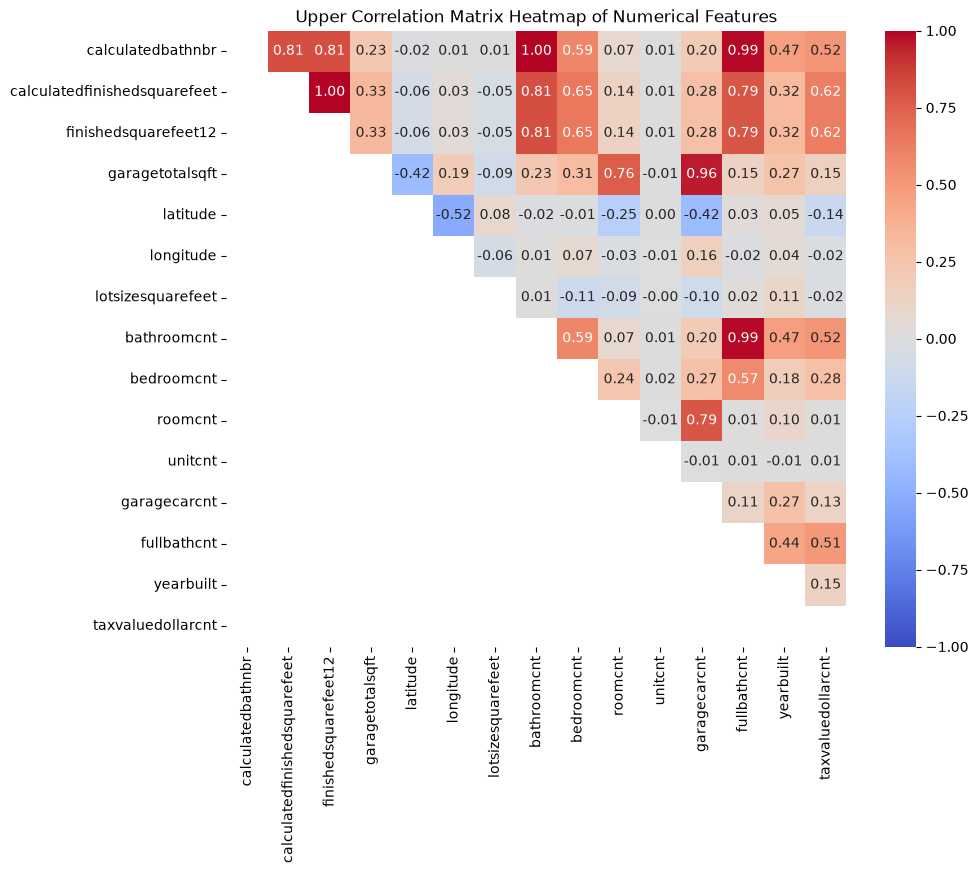

In [216]:
# heat map of the features
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) # avoids showing repeat correlations
plt.figure(figsize=(10, 8))
sns.heatmap(upper, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            center=0)

plt.title("Upper Correlation Matrix Heatmap of Numerical Features")

In [217]:
# highest correlation pairs:
high_corr = upper.stack()
high_corr = high_corr[
    (high_corr > 0.7) &
    (
        high_corr.index.get_level_values(0).isin(numerical_features) |
        high_corr.index.get_level_values(1).isin(numerical_features)
    )
]

print(high_corr)

calculatedbathnbr             calculatedfinishedsquarefeet    0.812604
                              finishedsquarefeet12            0.812604
                              bathroomcnt                     1.000000
                              fullbathcnt                     0.986380
calculatedfinishedsquarefeet  finishedsquarefeet12            1.000000
                              bathroomcnt                     0.812604
                              fullbathcnt                     0.786934
finishedsquarefeet12          bathroomcnt                     0.812604
                              fullbathcnt                     0.786934
garagetotalsqft               roomcnt                         0.757864
                              garagecarcnt                    0.957666
bathroomcnt                   fullbathcnt                     0.986380
roomcnt                       garagecarcnt                    0.785910
dtype: float64


Text(0, 0.5, 'Feature')

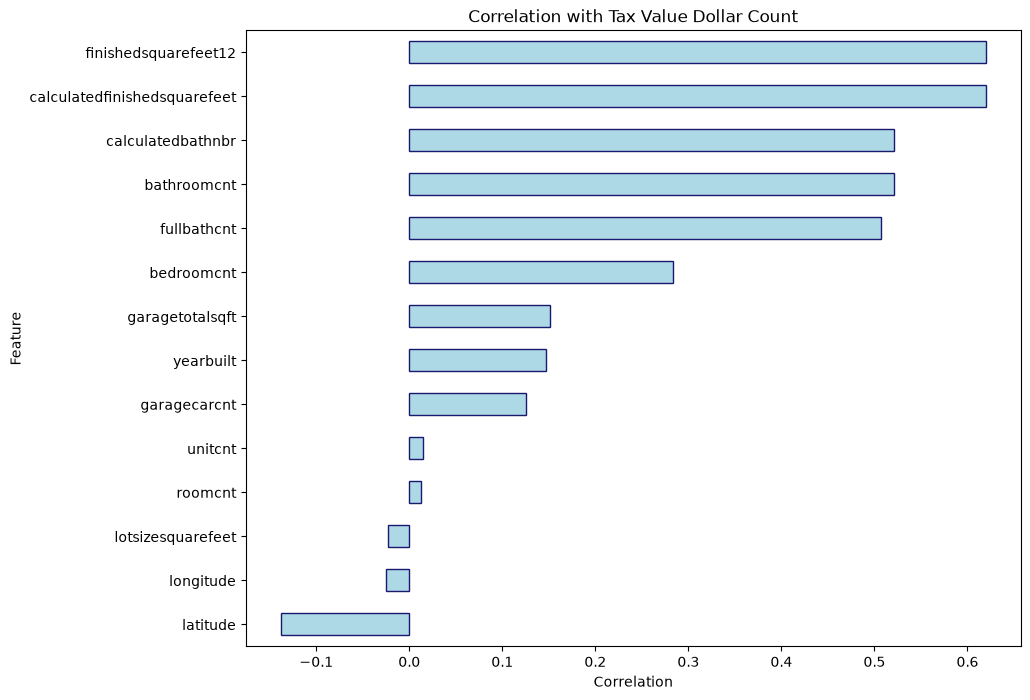

In [218]:
# bar chart of features

# get correlation matric without target variable
target_corr = corr_matrix["taxvaluedollarcnt"].drop("taxvaluedollarcnt").sort_values()

plt.figure(figsize=(10, 8))
target_corr.plot(kind="barh", color="lightblue", edgecolor="midnightblue")

plt.title("Correlation with Tax Value Dollar Count")
plt.xlabel("Correlation")
plt.ylabel("Feature")


In [219]:
# F-statistics (f_regression)

# drop object features
X_temp = X_train.drop(columns=["propertycountylandusecode", "propertyzoningdesc"])

# compute f-score and p-values
f_scores, p_values = f_regression(X_temp, y_train)

f_results = pd.DataFrame({
    "Feature": X_temp.columns,
    "F-Statistic": f_scores,
    "P-Value": p_values
})

f_results = f_results.sort_values("F-Statistic", ascending=False)
display(f_results)

,Feature,F-Statistic,P-Value
6,finishedsquarefeet12,31901.103948,0.000000e+00
5,calculatedfinishedsquarefeet,31901.103948,0.000000e+00
1,bathroomcnt,19035.535549,0.000000e+00
4,calculatedbathnbr,19035.535549,0.000000e+00
8,fullbathcnt,17770.603741,0.000000e+00
3,buildingqualitytypeid,4847.537381,0.000000e+00
2,bedroomcnt,4465.012612,0.000000e+00
10,garagetotalsqft,1200.813019,4.201859e-260
22,yearbuilt,1130.460763,3.741909e-245
12,latitude,991.338951,1.577064e-215


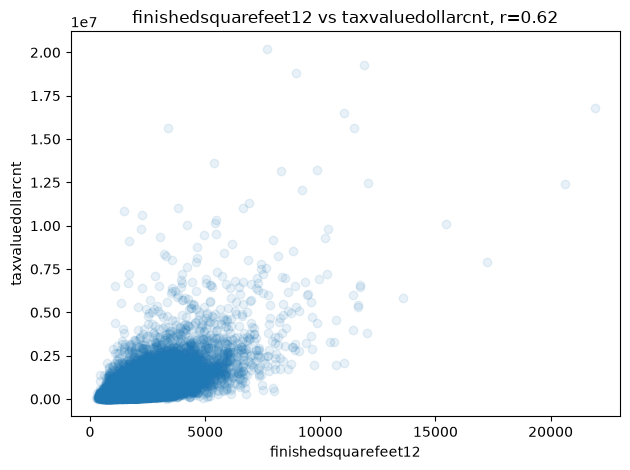

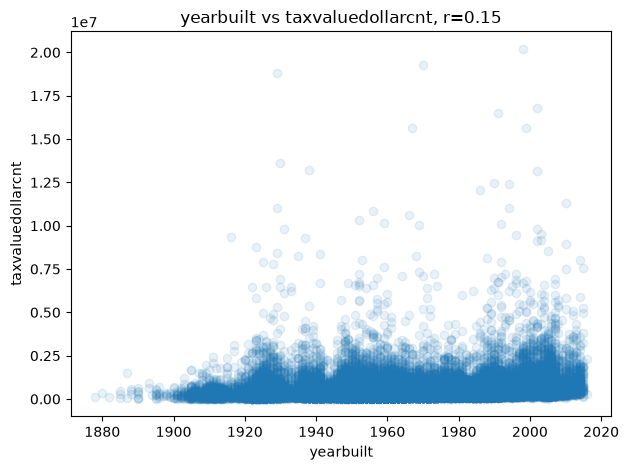

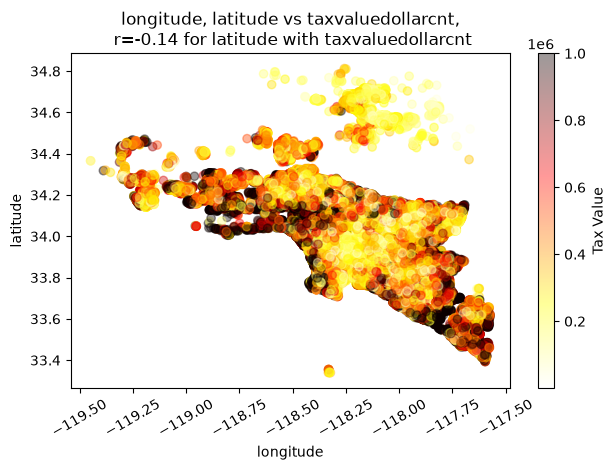

In [220]:
# chartting of 3 relationships for question 4B

temp_df = X_train.copy()
temp_df["taxvaluedollarcnt"] = y_train

# calculating correlation coefficients for the 3 relationships to embed in charts
corr_sqft = temp_df['finishedsquarefeet12'].corr(temp_df['taxvaluedollarcnt'])
corr_year = temp_df['yearbuilt'].corr(temp_df['taxvaluedollarcnt'])
corr_lat = temp_df['latitude'].corr(temp_df['taxvaluedollarcnt'])

# sqft vs taxvaluedollarcnt scatter plot
plt.figure()
plt.scatter(temp_df['finishedsquarefeet12'], temp_df['taxvaluedollarcnt'], alpha=0.1)
plt.xlabel('finishedsquarefeet12')
plt.ylabel('taxvaluedollarcnt')
plt.title(f'finishedsquarefeet12 vs taxvaluedollarcnt, r={corr_sqft:.2f}')
plt.tight_layout()
plt.show()

# year built vs taxvaluedollarcnt scatter plot
plt.figure()
plt.scatter(temp_df['yearbuilt'], temp_df['taxvaluedollarcnt'], alpha=0.1)
plt.xlabel('yearbuilt')
plt.ylabel('taxvaluedollarcnt')
plt.title(f'yearbuilt vs taxvaluedollarcnt, r={corr_year:.2f}')
plt.tight_layout()
plt.show()

# location, latitude vs taxvaluedollarcnt scatter plot
# lat/long divided by 1e6, ticks rotated so they don't crowd together
plt.figure()
plt.scatter(temp_df['longitude']/1e6, temp_df['latitude']/1e6, c=temp_df['taxvaluedollarcnt'], cmap='hot_r', alpha=0.4, vmax=1000000)
plt.colorbar(label='Tax Value')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.xticks(rotation=30)
plt.title(f'longitude, latitude vs taxvaluedollarcnt,\n r={corr_lat:.2f} for latitude with taxvaluedollarcnt')
plt.tight_layout()
plt.show()

#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to be the strongest predictors of the target.
- Which pairs of features appeared to be highly correlated.
- Whether the correlation matrix and the F-statistics led you to similar conclusions about the most important features. Explain your reasoning.

> __Features that appear to be the strongest predictors of the target:__ Based on the heatmap and the bar chart above, we believe the strongest preditors with our target, _taxvaluedollarcnt_, are _finishedsquarefeet12_ and _calculatedfinishedsquarefeet_. This is shown with correlations of 0.62 and visually with the longest bars on the bar graph.

> __Pairs of features that appear highly correlated:__ Based on our correlation matrix, pairs of feature that high strong postive correlations (above 0.7) are (_calculatedbathnbr_, _calculatedfinishedsquarefeet_), (_calculatedbathnbr_, _finishedsquarefeet12_), (_calculatedbathnbr_, _bathroomcnt_), (_calculatedbathnbr_, _fullbathcnt_), (_calculatedfinishedsquarefeet_, _finishedsquarefeet12_), (_calculatedfinishedsquarefeet_, _bathroomcnt_), (_calculatedfinishedsquarefeet_, _fullbathcnt_), (_finishedsquarefeet12_, _bathroomcnt_), (_finishedsquarefeet12_, _fullbathcnt_), (_bathroomcnt_, _fullbathcnt_), (_garagetotalsqft_, _roomcnt_), (_garagetotalsqft, garagecarcnt_), and (_roomcnt_, _garagecarcnt_). We believe that most of these pairs show high correlations because larger homes typically have more bathrooms and greater amounts of finished living space.

> __Correlation matrix vs F-statistics:__ Yes we reached similar conclusions using both the correlation matrix and f-statistics. Based on our f_regression above, it shows that the highest F-statistics are _finishedsquarefeet12_ and _calculatedfinishedsquarefeet_, which are also the features that had the highest correlations in our matrix. Since the F-statistic represents the features that are most significant to predicting our target variable and correlation measures how closely features change together, we essentially reached very similar conclusions despite using different methods.

#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to have the strongest relationships with the target.
- Whether any relationships suggest opportunities for future feature engineering or preprocessing in Milestone 2.

> __Features that appeared the have the strongest relationships with target:__ By using both a correlation matrix and f_regression, we believe that the strongest relationships with our target are _finishedsquarefeet12_ and _calculatedfinishedsquarefeet_. Since these two features display the highest F-statistics and strong positive correlations with out target variable, we believe that these relationships are the most important.

> __Any relationships that suggest opportunities for future engineering or preprocessing in Milestone 2:__ Based on the preprocessing done so far, we believe that we can possibly remove some of the features that are highly correlated due to redundancy. For example, there are three features that denote information about bathrooms: _calculatedbathnbr_, _bathroomcnt_, and _fullbathcnt_. Although these three features are slightly different, they all have strong positive linear correlations with one another that are greater than 0.98. Because of this, we believe that not all three features are necessary, and that one of them may be sufficient for future analysis. As for future engineering, we believe that ratios between bathrooms and bedroom count would be good for analysis. This is because based on out own experiences, we see high ratios of bathrooms to bedrooms in more expensive homes. We believe that both this processing and engineering methods will improve our models and will explore this further in Milestone 2.

> __Further insights for Milestone 2:__ When looking at our heatmap, it shows many relationships that have poor correlation. However, the correlation matrix is limited to measuring only linear relationships. For example, home prices do not simply increase or decrease as you move in a certain direction, instead, they are affected by clusters based on geographic location. Therefore, even though there might seem to be a low correlation based on the correlation matrix, there could still be a very strong non-linear relationship that is not being shown. Further, as shown in 2A and 2B, certain features like unitcnt only have 8 unique values, while roomcnt is overwhelmingly 0. This could also lead to misleading results in both our correlation matrix and the f_regression analysis due to the lack of unique values.

#### **4.B Discussion:**

Describe what you learned from the three feature relationships you investigated.

For each pair, discuss:

- The overall pattern you observed (for example, linear, nonlinear, weak, or strong).
- What the relationship suggests about the features and their potential usefulness for predicting the target.
- Whether your observations suggest possible feature engineering or preprocessing ideas that could be investigated in **Milestone 2**.

> __The overall pattern observed:__ We investigated three relationships: finishedsquarefeet12, yearbuilt, and latitude/longitude together, each against taxvaluedollarcnt. finishedsquarefeet12 shows a clear positive relationship with taxvaluedollarcnt (r=0.62), but the pattern is not a straight line, and most points sit close to the x-axis at lower square footage, then the spread widens and curves upward as square footage increases. yearbuilt shows a much weaker relationship (r=0.15), and the scatter shows both older and newer homes spanning a wide range of values rather than a simple upward trend with newer construction. latitude also shows a weak correlation on its own (r=-0.14), but when plotted together with longitude and colored by value, the pattern becomes much clearer: small, concentrated pockets of high value (such as coastal or hillside areas) stand out against much larger areas with little to no high-value activity, rather than a smooth gradient across the map.

> __What the relationship suggests about the features and their potential usefulness for predicting the target:__ finishedsquarefeet12 is clearly useful, but its non-linear shape suggests a plain linear model may undervalue the effect of size at the high end. yearbuilt on its own does not appear to be a strong predictor, likely because older architecturally distinct homes can be worth more than a newer plain apartment, so age alone does not consistently track with value. latitude and longitude individually look weak, but this is misleading. Location plays a role in home value, it just is not captured well by a single coordinate, since expensive areas form isolated clusters rather than following a directional trend.

> __Possible feature engineering or preprocessing ideas that could be investigated in Milestone 2:__ For finishedsquarefeet12, a log transformation could help straighten the curved relationship and make it easier for a linear model to fit. For yearbuilt, binning into eras (for example, pre-1950, 1950-1990, 1990+) could let a model treat different construction periods as their own groups rather than assuming value rises steadily with newer construction. For location, combining latitude and longitude into a clustering-based feature (such as grouping properties with KMeans) could let a model learn typical price by area, rather than trying to fit a straight line to raw coordinates that do not move linearly with price. These are potential directions we could explore further in Milestone 2.


## Part 5: Investigate Potential Feature Engineering [6 pts]

In this part, you will identify potential feature engineering and preprocessing techniques that **may** improve model performance.

The goal is to develop hypotheses based on your exploratory data analysis—not to permanently modify the dataset. In **Milestone 2**, you will evaluate these ideas experimentally and determine whether they actually improve the model.

**Important:** Do **not** permanently transform, remove, or add features in this milestone.

## Part 5.A: Identify Potential Feature Engineering Opportunities

Based on your exploratory analysis, identify **at least three (3)** feature engineering or preprocessing techniques that you believe may improve model performance.

Possible ideas include (but are not limited to):

- Log transformations
- Scaling or normalization
- Removing highly correlated features
- Polynomial features
- Interaction features
- Binning continuous variables
- Outlier removal
- Combining or aggregating existing features

You may investigate these ideas by creating visualizations or performing exploratory analyses, but **do not permanently modify the dataset**.

In [221]:
# show data preview with all columns visible in x_train after imputation and encoding
import pandas as pd
# Set max columns to None (unlimited)
pd.set_option('display.max_columns', None)
# Print your data
print(temp_df.head(2))


       airconditioningtypeid  bathroomcnt  bedroomcnt  buildingqualitytypeid  \
13225                    1.0          1.0         1.0                    5.0   
6479                     1.0          1.0         2.0                    5.0   

       calculatedbathnbr  calculatedfinishedsquarefeet  finishedsquarefeet12  \
13225                1.0                        1056.0                1056.0   
6479                 1.0                         860.0                 860.0   

         fips  fullbathcnt  garagecarcnt  garagetotalsqft  \
13225  6037.0          1.0           0.0              0.0   
6479   6037.0          1.0           0.0              0.0   

       heatingorsystemtypeid    latitude    longitude  lotsizesquarefeet  \
13225                    7.0  34671938.0 -118219608.0            53066.0   
6479                     7.0  33970247.0 -118243861.0             5444.0   

      propertycountylandusecode  propertylandusetypeid propertyzoningdesc  \
13225                      0

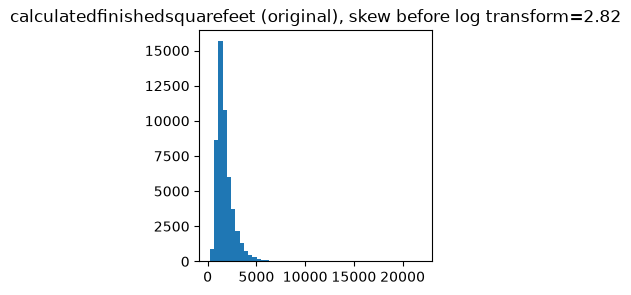

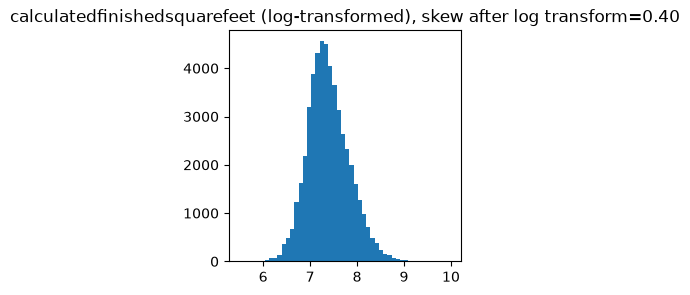

calculatedfinishedsquarefeet: skew before=2.82, skew after=0.40 



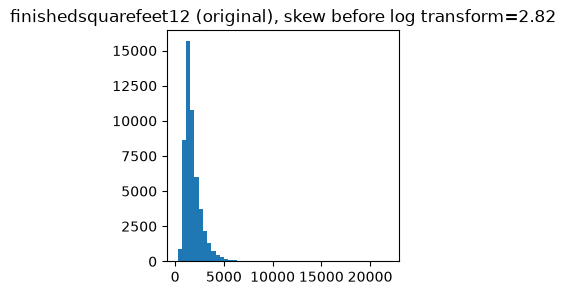

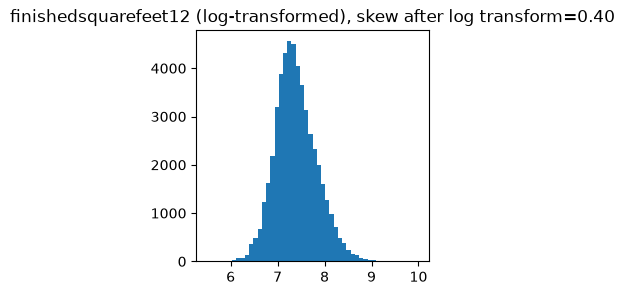

finishedsquarefeet12: skew before=2.82, skew after=0.40 



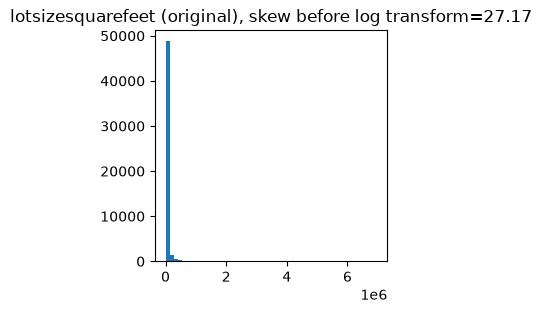

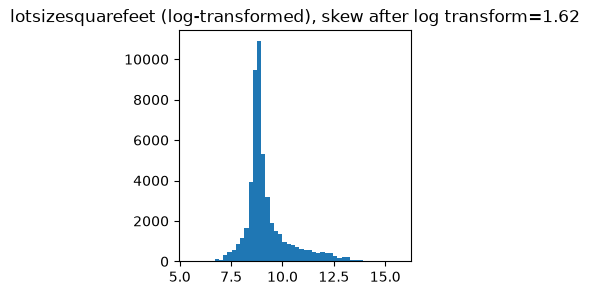

lotsizesquarefeet: skew before=27.17, skew after=1.62 



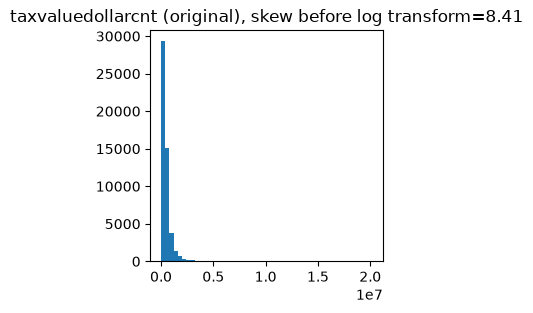

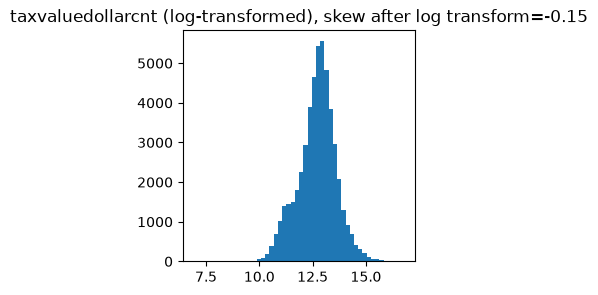

taxvaluedollarcnt: skew before=8.41, skew after=-0.15 



In [222]:
# Idea 1: log transform target and skewed features - before/after histograms + skew values
cols = ['calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'lotsizesquarefeet', 'taxvaluedollarcnt']

for col in cols:
    before = temp_df[col].skew()
    after = np.log1p(temp_df[col]).skew()

    plt.figure(figsize=(3, 3))
    plt.hist(temp_df[col], bins=50)
    plt.title(f'{col} (original), skew before log transform={before:.2f}')
    plt.show()

    plt.figure(figsize=(3, 3))
    plt.hist(np.log1p(temp_df[col]), bins=50)
    plt.title(f'{col} (log-transformed), skew after log transform={after:.2f}')
    plt.show()

    print(f"{col}: skew before={before:.2f}, skew after={after:.2f} \n")


In [223]:

# Idea 2: check feature scale differences
print("Feature scale differences for bathroom features(min to max values):")
for col in ['bathroomcnt', 'calculatedfinishedsquarefeet', 'lotsizesquarefeet']:
    print(f"{col}: {temp_df[col].min():,.0f} to {temp_df[col].max():,.0f}")
print("")

Feature scale differences for bathroom features(min to max values):
bathroomcnt: 1 to 13
calculatedfinishedsquarefeet: 242 to 21,929
lotsizesquarefeet: 236 to 6,971,010



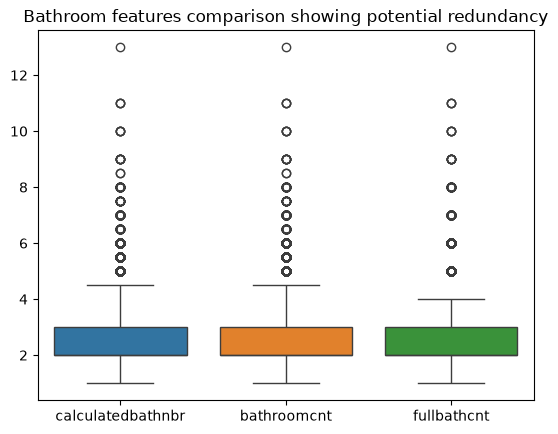

Correlation matrix for bathroom features:
                   calculatedbathnbr  bathroomcnt  fullbathcnt
calculatedbathnbr            1.00000      1.00000      0.98638
bathroomcnt                  1.00000      1.00000      0.98638
fullbathcnt                  0.98638      0.98638      1.00000


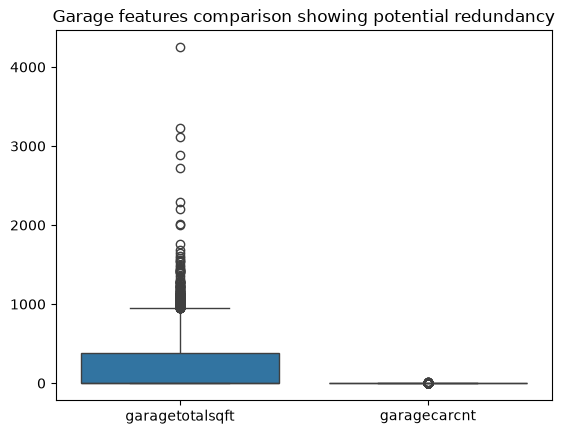

Correlation matrix for garage features:
                 garagetotalsqft  garagecarcnt
garagetotalsqft         1.000000      0.957666
garagecarcnt            0.957666      1.000000


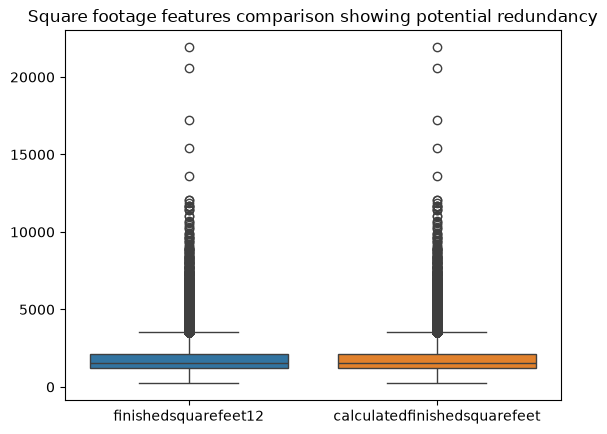

Correlation matrix for square footage features:
                              finishedsquarefeet12  \
finishedsquarefeet12                           1.0   
calculatedfinishedsquarefeet                   1.0   

                              calculatedfinishedsquarefeet  
finishedsquarefeet12                                   1.0  
calculatedfinishedsquarefeet                           1.0  


In [224]:

# Idea 3: check redundancy among highly correlated features with boxplots
# bathroom features
bath_cols = ['calculatedbathnbr', 'bathroomcnt', 'fullbathcnt']
sns.boxplot(data=temp_df[bath_cols])
plt.title('Bathroom features comparison showing potential redundancy')
plt.show()

print("Correlation matrix for bathroom features:")
print(temp_df[bath_cols].corr())

# garage features
garage_cols = ['garagetotalsqft', 'garagecarcnt']
sns.boxplot(data=temp_df[garage_cols])
plt.title('Garage features comparison showing potential redundancy')
plt.show()

print("Correlation matrix for garage features:")
print(temp_df[garage_cols].corr())

# square footage features
sqft_cols = ['finishedsquarefeet12', 'calculatedfinishedsquarefeet']
sns.boxplot(data=temp_df[sqft_cols])
plt.title('Square footage features comparison showing potential redundancy')
plt.show()

print("Correlation matrix for square footage features:")
print(temp_df[sqft_cols].corr())



#### **5.A Discussion:**

Describe the three feature engineering or preprocessing ideas you identified.

For each one, explain:

- Which feature(s) it would affect.
- Why you believe it may improve model performance.
- How you would determine in **Milestone 2** whether it actually improves the model (for example, by comparing appropriate evaluation metrics on a validation or test set).

> __Ideas of feature engineering identified:__ We identified three ideas based on our exploratory analysis: (1) log-transforming the target variable taxvaluedollarcnt and 3 heavily skewed variables calculatedfinishedsquarefeet, finishedsquarefeet12 and lotsizesquarefeet, (2) scaling continuous features such as calculatedfinishedsquarefeet and lotsizesquarefeet, and (3) removing highly correlated redundant features among bathroom features (calculatedbathnbr, bathroomcnt, and fullbathcnt) and squarefootage features (finishedsquarefeet12, calculatedfinishedsquarefeet).

> __Why they may improve model performance:__ The target and 3 variables calculatedfinishedsquarefeet, finishedsquarefeet12 and lotsizesquarefeet are heavily right-skewed, which can cause a small number of extremely high-value properties to disproportionately influence a model; log1p brings the skewness down, essentially normal. Continuous features exist on very different numeric scales. For example, bathroomcnt ranges from 1 to 13 while lotsizesquarefeet ranges up to nearly 7 million. Hence if without scaling, gradient-based or regularized models may weight features unevenly based on raw magnitude rather than actual predictive value. Finally, calculatedbathnbr and bathroomcnt are perfectly correlated (r=1.00), and both correlate with fullbathcnt at r=0.986, meaning these three features carry almost identical information and add redundant noise without adding new signal. And boxplots show that they have identical distributions so it's safe to say they are very much duplicated. finishedsquarefeet12 and calculatedfinishedsquarefeet are highly correlated with r = 1 and identical boxplot distribution, showing they are redundant with no extra signal; For garagetotalsqft and garagecarcnt, even though they are highly correlated with r = 0.96, their box plots show them having very differnt distributions, which is understandable since garagetotalsqft does not necessarily translate to garagecarcnt in real life fully, so will not remove them as redundant since they contain different signals while very correlated. 

> __How determine in Milestone 2 that they will actually improve model:__ For the log transform, we can train the same model on both the raw and log-transformed target and 3 variables, then exponentiate log-space predictions back to dollars, and compare RMSE/MAE on a validation set. For scaling, we can fit a linear or regularized model with and without scaling applied, and compare validation RMSE and coefficient stability. For redundant features, we can train a model with all three bathroom features versus keeping only one, and compare validation performance and coefficient stability between the two.


## Part 5.B: Prioritize Your Ideas

Not all feature engineering ideas are equally promising.

Based on your investigation, select the **two** ideas you believe are most likely to improve model performance.

Briefly explain why you selected these ideas over the others.

No code is required for this section.

#### **5.B Discussion:**

Suppose you had time to evaluate only **two** feature engineering or preprocessing ideas in **Milestone 2**.

For each one, explain:

- Which idea you would prioritize.
- Why you believe it is the most promising.
- What evidence from your exploratory analysis (such as feature distributions, missing values, feature relationships, or other observations) led you to this conclusion.

> __2 ideas prioritized:__ (1) Log-transforming the target variable taxvaluedollarcnt and 3 variables calculatedfinishedsquarefeet, finishedsquarefeet12 and lotsizesquarefeet, and (2) removing highly correlated redundant features among bathroom features (calculatedbathnbr, bathroomcnt, and fullbathcnt) and squarefootage featrues (finishedsquarefeet12, calculatedfinishedsquarefeet).

> __Why they are most promising:__ Both are backed by strong, unambiguous evidence and are low-risk to implement. The log transform addresses the target's distribution directly, which affects every downstream model regardless of which algorithm is ultimately chosen. Removing redundant features is a simple, low-effort fix with essentially no downside, since the dropped features carry almost no unique information beyond what is retained.

> __Evidence from exploratory analysis leading to the conclusion:__ The target and 3 variables's skew drops after a log1p transform as shown on after log transform histograms shown in part 4B, one of the clearest and largest improvements observed in our analysis. Separately, calculatedbathnbr and bathroomcnt are perfectly correlated (r=1.00), and both correlate with fullbathcnt at r=0.986, with idenitical boxplot distributions. And finishedsquarefeet12 and calculatedfinishedsquarefeet are highly correlated with r = 1 and identical boxplot distribution. These evidence is difficult to interpret any other way than genuine redundancy. We considered scaling as a third candidate given the extreme range differences between features, but prioritized redundancy removal first since its evidence came directly from our own correlation analysis, whereas scaling's benefit is more dependent on which model is ultimately used. Tree-based models like Random Forest are largely unaffected by feature scale, while linear or distance-based models would benefit more, so its impact is harder to predict without knowing the final model choice.


#### **5 Discussion:**

Describe in a paragraph why you chose these transformations and what you observed.

> __Reasons for choosing the transformation and what have observed:__ We chose the two transformations because the evidence behind them was the strongest and least ambiguous of everything we observed in our analysis. For the log transformation: earlier exploratory analysis showed the target and 3 variables  calculatedfinishedsquarefeet, finishedsquarefeet12 and lotsizesquarefeet were heavily right-skewed, and our Part 4B scatter plot confirmed a curved rather than linear relationship between square footage and value. This pointed directly to the target's distribution as something worth addressing first, since it affects how every downstream model interprets the data. For removing redundant features: the correlation matrix showed that calculatedbathnbr, bathroomcnt, and fullbathcnt are almost perfectly correlated with one another (r=0.986 or higher), same for finishedsquarefeet12 and calculatedfinishedsquarefeet(r=1). Three features that consistently move together at this level are very unlikely to each add unique information, and their identical boxplot distributions, all making this a clear, low-risk fix. We considered other ideas as well, such as scaling, binning yearbuilt, and clustering location, but these two stood out as having the clearest evidence. Both remain hypotheses at this stage rather than confirmed improvements. In Milestone 2, we can test each experimentally by comparing validation performance with and without the transformation applied, taking care to exponentiate predictions back to dollar values when evaluating a model trained on the log-transformed target.


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |



## Appendix 3: Flowchart for Identifying Feature Types

The following flowchart can help you identify the statistical type of each feature and determine an appropriate encoding strategy for categorical variables.



<img src="Appendix_3_screenshot.png" alt="Appendix 3 screenshot for flowchart" width="500">